# Data storytelling using matplotlib - bar chart

<div style="max-width: 60ch">

- [data source](https://www.kaggle.com/datasets/dmi3kno/newcarsalesnorway)

> in this lecture notebook I have chosed to copy the code throughout several different data storytelling transformations as it makes the notebook easier to follow 
> in reality when creating these storytelling graphs I'd build reusable functions to keep the code DRY

</div>


In [52]:
import pandas as pd
import duckdb
from constants import GRAY_1, GRAY_2, GRAY_3, BLUE_1


df = pd.read_csv("data/norway_new_car_sales_by_make.csv")
df.head()

,Year,Month,Make,Quantity,Pct
0,2007,1,Toyota,2884,22.7
1,2007,1,Volkswagen,2521,19.9
2,2007,1,Peugeot,1029,8.1
3,2007,1,Ford,870,6.9
4,2007,1,Volvo,693,5.5


In [53]:
df_quantity_brand = duckdb.query(
    """
             SELECT make AS Brand, SUM(quantity) as Quantity 
             FROM df 
             GROUP BY make 
             ORDER BY quantity DESC"""
).df().set_index("Brand")

df_quantity_brand.head()

,Quantity
Brand,
Volkswagen,206669.0
Toyota,168177.0
Volvo,99937.0
Ford,99713.0
BMW,73315.0


## Bar charts

### initial chart

- very hard to read
- many car brands that don't get bought too much


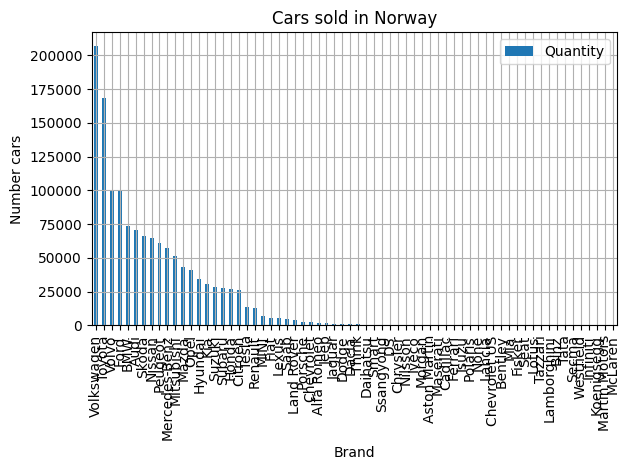

In [54]:
# using dataframes plot method which is a wrapper for matplotlib
ax = df_quantity_brand.plot(
    kind="bar",
    y="Quantity",
    title="Cars sold in Norway",
    ylabel="Number cars",
)
ax.grid()
fig = ax.get_figure()
fig.tight_layout()
fig.savefig("figures/cars_sold_0.png")

## remove clutter

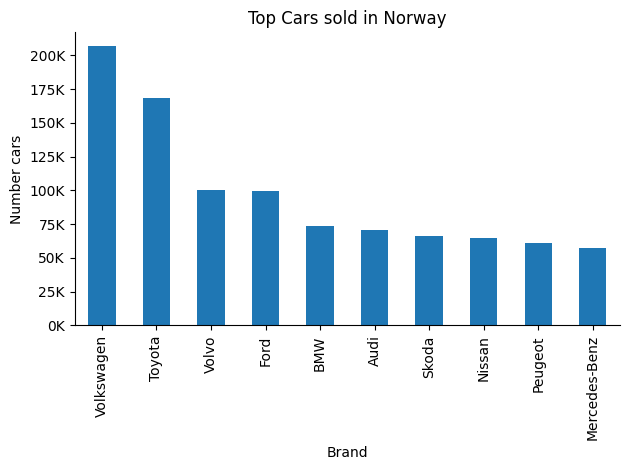

In [55]:
from matplotlib.ticker import FuncFormatter

# using dataframes plot method which is a wrapper for matplotlib
ax = df_quantity_brand.iloc[:10].plot(
    kind="bar",
    y="Quantity",
    title="Top Cars sold in Norway",
    ylabel="Number cars",
)

ax.legend().remove()
ax.spines[["top", "right"]].set_visible(False)
formatter = FuncFormatter(lambda val, pos: f"{int(val/1000)}K")
ax.yaxis.set_major_formatter(formatter)


fig = ax.get_figure()
fig.tight_layout()
fig.savefig("figures/cars_sold_1.png")

### horizontal bar chart 

- might be better when dealing with many bars
- 

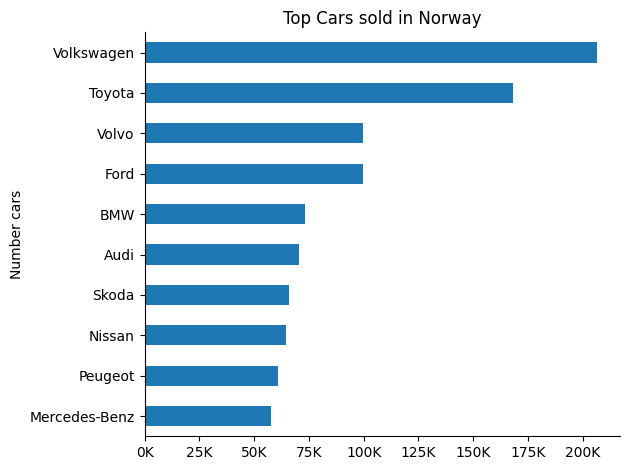

In [56]:
from matplotlib.ticker import FuncFormatter

# using dataframes plot method which is a wrapper for matplotlib
ax = df_quantity_brand.iloc[:10].sort_values(by="Quantity", ascending=False).plot(
    kind="barh",
    y="Quantity",
    title="Top Cars sold in Norway",
    ylabel="Number cars",
)

# requires since horizontal bars place first row in bottom by default
ax.invert_yaxis() 
ax.legend().remove()
ax.spines[["top", "right"]].set_visible(False)
formatter = FuncFormatter(lambda val, pos: f"{int(val/1000)}K")
ax.xaxis.set_major_formatter(formatter)


fig = ax.get_figure()
fig.tight_layout()
fig.savefig("figures/cars_sold_2.png")